# 02 - Photovoltaic units on the CIGRE MV feeder: when and where overvoltage appears

This notebook adds distributed photovoltaic (PV) generation to feeder 1 of the CIGRE
European MV benchmark (CIGRE TB 575, Section 6.2) and asks a simple question: at which
buses, and from what level of PV output and load, does the feeder voltage leave the
0.95 to 1.05 pu band?

The feeder is the radial base case of `cigre_dss.py` (validated against pandapower to
about 1e-5 %). The brochure's own DER case (Table 6.18) places PV of a few tens of kW at
eight buses of feeder 1 and a 1.5 MW wind turbine at bus 7. Those PV sizes are far too
small to disturb a 20 kV feeder, so the PV ratings are taken instead from Wagle et al.
(2023), who used the same nine buses with about 680 to 740 kW of PV each (wind at bus 7
replaced by PV) for a Volt-Var control study of this network. Lines, transformers and
loads stay as in the data file; the loads are moved through the day with the brochure's
daily profiles (Figure 6.4, in the data file as `load_profiles`). The TR1 tap is set
for a feeder with generation in step 2 and then kept for the rest of the study.

Steps:

1. DER units of the brochure and the PV ratings used here.
2. Transformer tap for a feeder with PV: scan of the TR1 tap at the two load extremes.
3. Four snapshot cases: evening peak, midday load without PV, midday with PV, midday with PV and a meshed feeder 1.
4. Voltage profile along both feeders for the four cases.
5. Irradiance sweep at midday load: maximum feeder-1 voltage and power flow at TR1 and at the feeder head.
6. Load level: at which load does full PV output violate the limit.
7. Voltage at each PV bus at full output.
8. Summary.

In [1]:
# Paths: this notebook runs from notebooks/, the modules live in src/ and every
# generated file in results/, so the working directory is moved there once.
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    sys.path.insert(0, os.path.abspath(os.path.join(os.pardir, "src")))
    os.makedirs(os.path.join(os.pardir, "results"), exist_ok=True)
    os.chdir(os.path.join(os.pardir, "results"))

import math, json
import numpy as np
import matplotlib.pyplot as plt
import opendssdirect as dss

import cigre_dss as cd

d = cd.load_data()
print("opendssdirect", dss.__version__, "| OpenDSS engine:", dss.Basic.Version()[:40])

opendssdirect 0.9.4 | OpenDSS engine: DSS C-API Library version 0.14.5 revisio


## 1. DER units: brochure table and the ratings used

The brochure's DER case study (Section 6.2.5, Table 6.18, p.58) is reproduced below from
the data file. Nine buses of feeder 1 carry PV or wind: 3, 4, 5, 6, 8, 9, 10, 11 (PV)
and 7 (wind). The CHP, fuel-cell and battery entries are listed for completeness only;
they are dispatchable units whose output is a study assumption rather than a property
of the network, and they are not modelled here.

The PV ratings used are Table 1 of

> R. Wagle, P. Sharma, M. Amin, J. L. Rueda, F. Gonzalez-Longatt, "Real-time Volt-Var
> control of grid forming converters in DER-enriched distribution network", *Frontiers in
> Energy Research* 10:1054870, 2023, Table 1 (ratings attributed there to Barsali
> et al., 2014).

That table gives only $P_\mathrm{max}$; no kVA or kvar rating is quoted. The inverter
rating is taken as 1.1 times $P_\mathrm{mpp}$, which gives the Category B reactive
capability of IEEE 1547-2018 (0.44 pu of rated kVA) at full active output. In this
notebook the units run at unity power factor; reactive support is the subject of later
notebooks. The dict is `cigre_dss.PV_KW`.

`cigre_dss.add_pv` creates one three-phase `PVSystem` per bus (`kv=20`, `pmpp=kW`,
`kva=1.1*kW`, `irradiance=1`, `pf=1`). The unit is left at 25 C with no temperature or
efficiency curve, so its output is irradiance times `pmpp`, which is what a snapshot
study needs. `vminpu`/`vmaxpu` are widened to 0.5/1.5 so that the unit stays a
constant-power injection in the overvoltage cases; the OpenDSS default of 1.1 pu would
otherwise turn it into a constant-impedance element and soften the very effect under
study.

In [2]:
print("Brochure DER units (Table 6.18, p.58)")
print(f"{'bus':>3s}  {'type':22s} {'Pmax kW':>8s}  used here")
pv_buses = sorted({u["bus"] for u in d["der_units"] if u["type"] in ("Photovoltaic", "Wind turbine")})
for u in d["der_units"]:
    used = "yes (as PV)" if u["type"] in ("Photovoltaic", "Wind turbine") else "no"
    print(f"{u['bus']:3d}  {u['type']:22s} {u['P_max_kW']:8.0f}  {used}")
tot_pv_tb = sum(u["P_max_kW"] for u in d["der_units"] if u["type"] == "Photovoltaic")
print(f"\nbrochure PV total {tot_pv_tb} kW at buses {[u['bus'] for u in d['der_units'] if u['type']=='Photovoltaic']}, "
      f"wind {[u['P_max_kW'] for u in d['der_units'] if u['type']=='Wind turbine'][0]} kW at bus 7")

assert pv_buses == sorted(cd.PV_KW), "PV/wind buses of the brochure and of the Wagle et al. table differ"
print("\nPV ratings used (Wagle et al. 2023, Table 1)")
print(f"{'bus':>3s} {'Pmpp kW':>8s} {'kVA':>7s}")
for b, kw in cd.PV_KW.items():
    print(f"{b:3d} {kw:8.0f} {1.1*kw:7.0f}")
PV_TOTAL_KW = sum(cd.PV_KW.values())
print(f"total {PV_TOTAL_KW/1e3:.2f} MW of PV on feeder 1, all at unity power factor")

Brochure DER units (Table 6.18, p.58)
bus  type                    Pmax kW  used here
  3  Photovoltaic                 20  yes (as PV)
  4  Photovoltaic                 20  yes (as PV)
  5  Photovoltaic                 30  yes (as PV)
  5  Battery                     600  no
  5  Residential fuel cell        33  no
  6  Photovoltaic                 30  yes (as PV)
  7  Wind turbine               1500  yes (as PV)
  8  Photovoltaic                 30  yes (as PV)
  9  Photovoltaic                 30  yes (as PV)
  9  CHP diesel                  310  no
  9  CHP fuel cell               212  no
 10  Photovoltaic                 40  yes (as PV)
 10  Battery                     200  no
 10  Residential fuel cell        14  no
 11  Photovoltaic                 10  yes (as PV)

brochure PV total 210 kW at buses [3, 4, 5, 6, 8, 9, 10, 11], wind 1500 kW at bus 7

PV ratings used (Wagle et al. 2023, Table 1)
bus  Pmpp kW     kVA
  3      690     759
  4      690     759
  5      680     748
  6

## 2. Transformer tap for a feeder with PV

The brochure tap of TR1 (+6.25 % on the 20 kV side, Table 9.7) is a peak-load setting:
it lifts the far end of feeder 1 to about 0.96 pu at full load. Once generation is
present, the light-load hours matter as much as the peak. The first cell below shows
that at +6.25 % bus 1 alone, without any PV, exceeds 1.05 pu whenever the total load
falls below about 0.4 pu of peak, which the brochure's daily profiles do every night.

A study of PV-induced overvoltage needs a tap at which the feeder without PV is inside
the band at all load levels, so that every violation that follows can be attributed to
PV. The second cell scans the TR1 tap in the 0.625 % steps of the on-load tap changer
(Table 6.13) at the lightest and the heaviest load level of the brochure daily
profiles (residential and commercial/industrial scaled separately, no PV) and lists the
minimum and maximum feeder-1 voltage at each setting. TR2 is not part of the question
and keeps its brochure tap (+3.125 %).

**Load levels.** The brochure gives daily profiles of residential and
commercial/industrial demand in pu of the node peak (Figure 6.4, 30-minute steps); the
Table 6.15 values are the peaks. The total load in pu of peak at each half hour is the
sum of the two sectors weighted by their peak MW. `cigre_dss.scale_loads(res_pu, ci_pu)`
scales the two sectors separately, P and Q together, because the profiles are in pu of
apparent power.

In [3]:
prof = d["load_profiles"]
peak_res = sum(ld["residential"]["P_kW_derived"] or 0 for ld in d["loads"])
peak_ci = sum(ld["commercial_industrial"]["P_kW_derived"] or 0 for ld in d["loads"])
def total_pu(res_pu, ci_pu):
    return (peak_res * res_pu + peak_ci * ci_pu) / (peak_res + peak_ci)
levels = [(r["t_h"], r["S_pu_of_max"], c["S_pu_of_max"])
          for r, c in zip(prof["residential"], prof["commercial_industrial"])]
LIGHT = min(levels, key=lambda x: total_pu(x[1], x[2]))
HEAVY = max(levels, key=lambda x: total_pu(x[1], x[2]))
print(f"peak load: residential {peak_res/1e3:.2f} MW, commercial/industrial {peak_ci/1e3:.2f} MW")
print(f"lightest level {LIGHT[0]:4.1f} h: residential {LIGHT[1]:.2f}, c/i {LIGHT[2]:.2f} -> total {total_pu(*LIGHT[1:]):.3f} pu of peak")
print(f"heaviest level {HEAVY[0]:4.1f} h: residential {HEAVY[1]:.2f}, c/i {HEAVY[2]:.2f} -> total {total_pu(*HEAVY[1:]):.3f} pu of peak")

def feeder1_minmax(tap, res_pu, ci_pu):
    cd.build_circuit(tr1_tap_pct=tap)
    cd.scale_loads(res_pu, ci_pu)
    cd.solve()
    v = cd.bus_voltages_pu()
    return min(v[b] for b in range(1, 12)), max(v[b] for b in range(1, 12)), v[1]

# bus 1 at the brochure tap, no PV, load scaled uniformly from peak downwards
thr = next(s for s in np.arange(1.0, 0.0, -0.01) if feeder1_minmax(6.25, s, s)[2] > 1.05)
print(f"\nbrochure tap +6.25 %, no PV: bus 1 exceeds 1.05 pu once the total load falls below {thr:.2f} pu of peak")

peak load: residential 33.57 MW, commercial/industrial 11.17 MW
lightest level  2.5 h: residential 0.18, c/i 0.29 -> total 0.207 pu of peak
heaviest level 19.0 h: residential 0.92, c/i 0.46 -> total 0.805 pu of peak



brochure tap +6.25 %, no PV: bus 1 exceeds 1.05 pu once the total load falls below 0.39 pu of peak


TR1 tap % | light: min     max | heavy: min     max | inside 0.95..1.05
    0.000 |     0.9830  0.9943 |     0.9177  0.9719 | no
    0.625 |     0.9893  1.0005 |     0.9243  0.9780 | no
    1.250 |     0.9957  1.0068 |     0.9308  0.9841 | no
    1.875 |     1.0020  1.0130 |     0.9373  0.9903 | no
    2.500 |     1.0083  1.0192 |     0.9439  0.9964 | no
    3.125 |     1.0147  1.0255 |     0.9504  1.0025 | yes
    3.750 |     1.0210  1.0317 |     0.9569  1.0086 | yes
    4.375 |     1.0273  1.0379 |     0.9634  1.0147 | yes
    5.000 |     1.0337  1.0442 |     0.9699  1.0208 | yes
    5.625 |     1.0400  1.0504 |     0.9764  1.0269 | no
    6.250 |     1.0463  1.0566 |     0.9829  1.0330 | no

TR1 tap fixed at +4.375 % for the rest of the study: feeder 1 lies within 0.9634 to 1.0379 pu at the two load extremes without PV


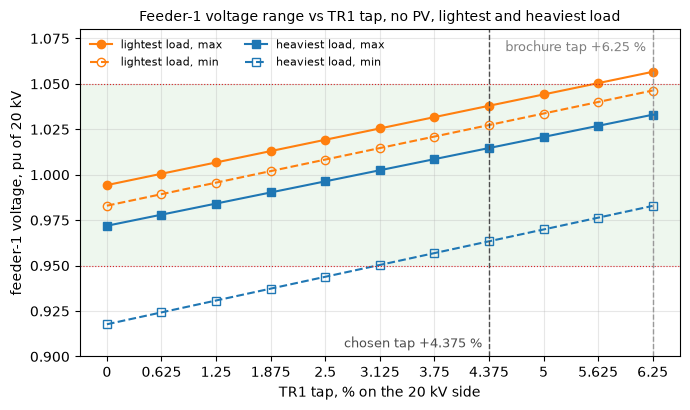

In [4]:
taps = np.round(np.arange(0.0, 6.25 + 1e-9, 0.625), 3)
scan = {tap: (feeder1_minmax(tap, LIGHT[1], LIGHT[2]), feeder1_minmax(tap, HEAVY[1], HEAVY[2])) for tap in taps}
print(f"{'TR1 tap %':>9s} | {'light: min':>10s} {'max':>7s} | {'heavy: min':>10s} {'max':>7s} | inside 0.95..1.05")
ok = []
for tap in taps:
    (lmin, lmax, _), (hmin, hmax, _) = scan[tap]
    inside = lmax <= 1.05 and hmin >= 0.95
    ok.append(inside)
    print(f"{tap:9.3f} | {lmin:10.4f} {lmax:7.4f} | {hmin:10.4f} {hmax:7.4f} | {'yes' if inside else 'no'}")
TR1_TAP = 4.375
assert scan[TR1_TAP][0][1] <= 1.05 and scan[TR1_TAP][1][0] >= 0.95
print(f"\nTR1 tap fixed at +{TR1_TAP} % for the rest of the study: feeder 1 lies within "
      f"{scan[TR1_TAP][1][0]:.4f} to {scan[TR1_TAP][0][1]:.4f} pu at the two load extremes without PV")

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.axhspan(0.95, 1.05, color="tab:green", alpha=0.08, lw=0)
ax.plot(taps, [scan[t][0][1] for t in taps], "o-", color="tab:orange", label="lightest load, max")
ax.plot(taps, [scan[t][0][0] for t in taps], "o--", color="tab:orange", mfc="none", label="lightest load, min")
ax.plot(taps, [scan[t][1][1] for t in taps], "s-", color="tab:blue", label="heaviest load, max")
ax.plot(taps, [scan[t][1][0] for t in taps], "s--", color="tab:blue", mfc="none", label="heaviest load, min")
for y in (0.95, 1.05):
    ax.axhline(y, color="tab:red", lw=0.8, ls=":")
ax.axvline(TR1_TAP, color="0.3", lw=1, ls="--")
ax.text(TR1_TAP - 0.08, 0.905, f"chosen tap +{TR1_TAP} %", fontsize=9, color="0.3", ha="right")
ax.axvline(6.25, color="0.6", lw=1, ls="--")
ax.text(6.25 - 0.08, 1.068, "brochure tap +6.25 %", fontsize=9, color="0.5", ha="right")
ax.set_xticks(taps); ax.set_xticklabels([f"{t:g}" for t in taps])
ax.set_xlabel("TR1 tap, % on the 20 kV side"); ax.set_ylabel("feeder-1 voltage, pu of 20 kV")
ax.set_ylim(0.90, 1.08); ax.grid(alpha=0.3)
ax.set_title("Feeder-1 voltage range vs TR1 tap, no PV, lightest and heaviest load", fontsize=10)
ax.legend(loc="upper left", fontsize=8, frameon=False, ncol=2)
plt.tight_layout(); plt.show()

Two settings keep feeder 1 inside the band at both extremes, +4.375 % and +5.0 %.
The lower one, +4.375 %, is chosen: it leaves the larger margin on the upper side
(about 1.2 % at light load against 0.6 % at +5.0 %), which is the side that PV pushes
against, while still keeping the peak-load minimum above 0.96 pu. From here on
`build_circuit` is always called with `tr1_tap_pct=TR1_TAP`; TR2 is unchanged.

## 3. Four snapshot cases

**Instants.** Two instants of the brochure daily profiles are used:

- *midday*: the lower-load of 12:00 and 13:00 (the code below picks it by total MW),
  which is when PV output peaks on a clear day;
- *evening peak*: 19:00, the residential maximum, with PV output zero.

**Cases.** (a) evening peak, no PV; (b) midday load, no PV; (c) midday load, PV at
100 % irradiance; (d) as (c) with switches S2 and S3 closed, which turns feeder 1 into
two loops (6-7 and 11-4) and shows how much a meshed topology helps. S1 stays open in
all cases so that feeder 2 remains an undisturbed reference.

Each case is a fresh build (`build_circuit`, `add_pv`, `scale_loads`,
`set_pv_irradiance`, `solve`), and case (c) is cross-checked against a pandapower
solution with the same PV (unity-pf static generators), load scaling and tap.

In [5]:
def pu_at(sec, t_h):
    return next(r["S_pu_of_max"] for r in prof[sec] if r["t_h"] == t_h)
print(f"{'time':>5s} {'res pu':>7s} {'c/i pu':>7s} {'total MW':>9s} {'pu of peak':>11s}")
cand = {}
for t in (12.0, 13.0, 19.0):
    r, c = pu_at("residential", t), pu_at("commercial_industrial", t)
    cand[t] = (r, c, (peak_res * r + peak_ci * c) / 1e3)
    print(f"{t:5.1f} {r:7.2f} {c:7.2f} {cand[t][2]:9.2f} {total_pu(r, c):11.3f}")
t_mid = min((12.0, 13.0), key=lambda t: cand[t][2])
MID = cand[t_mid][:2]; EVE = cand[19.0][:2]
print(f"midday case = {t_mid:.0f}:00  (residential {MID[0]}, c/i {MID[1]} pu of peak); evening = 19:00 ({EVE[0]}, {EVE[1]})")

def run_case(res_pu, ci_pu, irradiance, closed=()):
    cd.build_circuit(closed_switches=closed, tr1_tap_pct=TR1_TAP)
    cd.add_pv(cd.PV_KW)
    cd.scale_loads(res_pu, ci_pu)
    cd.set_pv_irradiance(irradiance)
    cd.solve()
    return dict(v=cd.bus_voltages_pu(), trf=cd.transformer_results(), pv=cd.pv_results(),
                head=cd.line_pq(1), grid=cd.grid_pq())

cases = {
    "(a) evening peak, no PV":            run_case(*EVE, 0.0),
    "(b) midday, no PV":                  run_case(*MID, 0.0),
    "(c) midday, PV 100 %":               run_case(*MID, 1.0),
    "(d) midday, PV 100 %, S2+S3 closed": run_case(*MID, 1.0, ("S2", "S3")),
}

# cross-check of case (c) against pandapower with the same PV, load scaling and tap
v_pp, _, _, _ = cd.pandapower_reference(d, pv_kw=cd.PV_KW, sector_scale=MID, tr1_tap_pct=TR1_TAP)
vc = cases["(c) midday, PV 100 %"]["v"]
worst_c = max(abs(vc[b] * (110 if b == 0 else 20) / v_pp[b]["v_kv"] - 1) * 100 for b in range(15))
print(f"\ncase (c) worst |OpenDSS - pandapower| = {worst_c:.6f} %")
assert worst_c < 0.05

print(f"\n{'bus':>3s}" + "".join(f"{k.split(',')[0]:>14s}" for k in cases))
for b in range(1, 15):
    row = "".join(f"{c['v'][b]:14.4f}" for c in cases.values())
    flag = "  <-- feeder 2" if b == 12 else ""
    print(f"{b:3d}{row}{flag}")
print("\nmax feeder-1 voltage, TR1 HV-side P, feeder-head (segment 1) P, PV output:")
for k, c in cases.items():
    vmax, bmax = max((c["v"][b], b) for b in range(1, 12))
    n_viol = sum(c["v"][b] > 1.05 for b in range(1, 12))
    print(f"  {k:38s} max {vmax:.4f} pu at bus {bmax:2d}, {n_viol:2d} buses > 1.05 | "
          f"TR1 {c['trf']['TR1']['p_hv_mw']:+7.3f} MW, seg1 {c['head'][0]:+6.3f} MW, PV {sum(x['p_kw'] for x in c['pv'].values())/1e3:.2f} MW")

 time  res pu  c/i pu  total MW  pu of peak
 12.0    0.73    0.83     33.78       0.755
 13.0    0.66    0.86     31.76       0.710
 19.0    0.92    0.46     36.02       0.805
midday case = 13:00  (residential 0.66, c/i 0.86 pu of peak); evening = 19:00 (0.92, 0.46)



case (c) worst |OpenDSS - pandapower| = 0.000007 %


bus(a) evening peak    (b) midday    (c) midday    (d) midday

  1        1.0147        1.0170        1.0197        1.0198

  2        0.9970        1.0014        1.0265        1.0268

...


max feeder-1 voltage, TR1 HV-side P, feeder-head (segment 1) P, PV output:

  (a) evening peak, no PV                max 1.0147 pu at bus  1,  0 buses > 1.05 | TR1 +19.719 MW, seg1 +3.678 MW, PV 0.00 MW

  (b) midday, no PV                      max 1.0170 pu at bus  1,  0 buses > 1.05 | TR1 +17.218 MW, seg1 +3.142 MW, PV 0.00 MW

  (c) midday, PV 100 %                   max 1.0409 pu at bus  7,  0 buses > 1.05 | TR1 +10.781 MW, seg1 -3.287 MW, PV 6.44 MW

  (d) midday, PV 100 %, S2+S3 closed     max 1.0399 pu at bus  7,  0 buses > 1.05 | TR1 +10.777 MW, seg1 -3.291 MW, PV 6.44 MW

Without PV the profile falls from about 1.015 to 1.017 pu at bus 1 to 0.963 to 0.97 pu
at the far buses. With 6.4 MW of PV at the weekday midday load the whole of feeder 1
beyond bus 2 rises by about 6 %, the highest voltage sitting at bus 7, the end of the
8-7 lateral, at about 1.041 pu: still inside the band at this load level. Closing S2 and
S3 flattens the profile slightly (the loops share the injection between more cables) but
the level hardly changes, because the rise is set by the total PV power flowing back
through the long segments 1 and 2 (2.82 + 4.42 km) towards the transformer, and the
loops do not shorten that path. Feeder 2 is untouched in all cases.

Two flows are shown because they differ in sign. TR1 always carries power from the
110 kV grid: its secondary also feeds the 15 MVA lumped load at bus 1, which stands for
the other feeders on the same transformer and exceeds the PV output on its own. The
feeder itself, read at segment 1 leaving bus 1, reverses at full PV output.

## 4. Voltage profile along the feeders

Feeder 1 buses 1 to 11 (x-axis is the bus number, the connecting lines are a visual
aid), feeder 2 buses 12 to 14. Dotted red lines mark 0.95 and 1.05 pu; the shaded
columns are the PV buses.

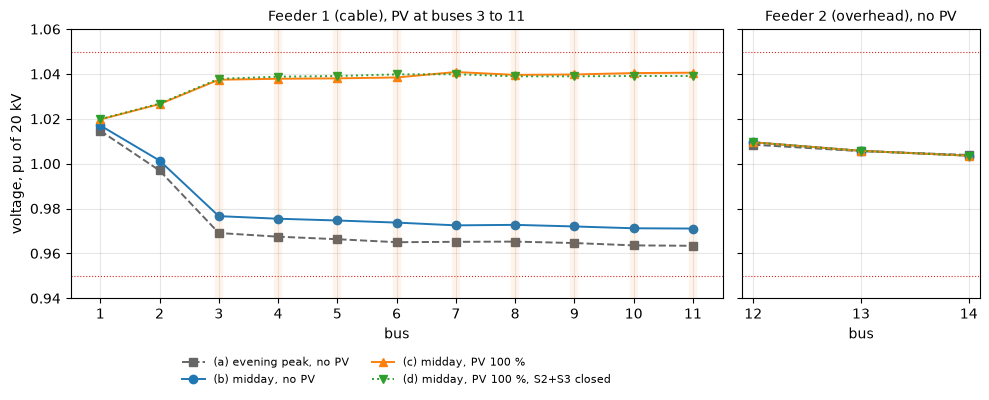

In [6]:
f1 = list(range(1, 12)); f2 = [12, 13, 14]
styles = {"(a) evening peak, no PV": dict(color="0.4", marker="s", ls="--"),
          "(b) midday, no PV": dict(color="tab:blue", marker="o", ls="-"),
          "(c) midday, PV 100 %": dict(color="tab:orange", marker="^", ls="-"),
          "(d) midday, PV 100 %, S2+S3 closed": dict(color="tab:green", marker="v", ls=":")}
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True, gridspec_kw=dict(width_ratios=[11, 4]))
for ax, buses, title in zip(axes, (f1, f2), ("Feeder 1 (cable), PV at buses 3 to 11", "Feeder 2 (overhead), no PV")):
    for k, c in cases.items():
        ax.plot(buses, [c["v"][b] for b in buses], ms=6, lw=1.4, label=k, **styles[k])
    for y in (0.95, 1.05):
        ax.axhline(y, color="tab:red", lw=0.8, ls=":")
    ax.set_xticks(buses); ax.set_xlabel("bus"); ax.set_title(title, fontsize=10); ax.grid(alpha=0.3)
for b in cd.PV_KW:
    axes[0].axvline(b, color="tab:orange", lw=6, alpha=0.08)
axes[0].set_ylabel("voltage, pu of 20 kV"); axes[0].set_ylim(0.94, 1.06)
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

## 5. Irradiance sweep at midday load

PV output is now varied from 0 to 100 % of $P_\mathrm{mpp}$ (radial feeder, midday
load). The circuit is built once and only the irradiance changes between solves. A fine
sweep in 0.01 steps locates the irradiance at which the first bus reaches 1.05 pu, if
any. The lower panel shows the active power at the HV side of TR1 and at the head of
feeder 1 (segment 1, bus 1 towards bus 2); negative values mean reverse flow.

 irr  max V pu at bus >1.05   TR1 MW  seg1 MW

 0.0    1.0170      1     0  +17.218   +3.142

 0.1    1.0177      1     0  +16.536   +2.461

 0.2    1.0182      1     0  +15.863   +1.789

 0.3    1.0187      1     0  +15.200   +1.127

...

 0.9    1.0351      7     0  +11.390   -2.679

 1.0    1.0409      7     0  +10.781   -3.287


no bus reaches 1.05 pu at this load: maximum 1.0409 pu at bus 7 at full output

feeder-1 head (segment 1) reverses at irradiance 0.48 (PV output 3.09 MW)

TR1 HV-side P at full output: +10.781 MW (no reversal: the bus-1 lumped load alone is 14.06 MW at midday)

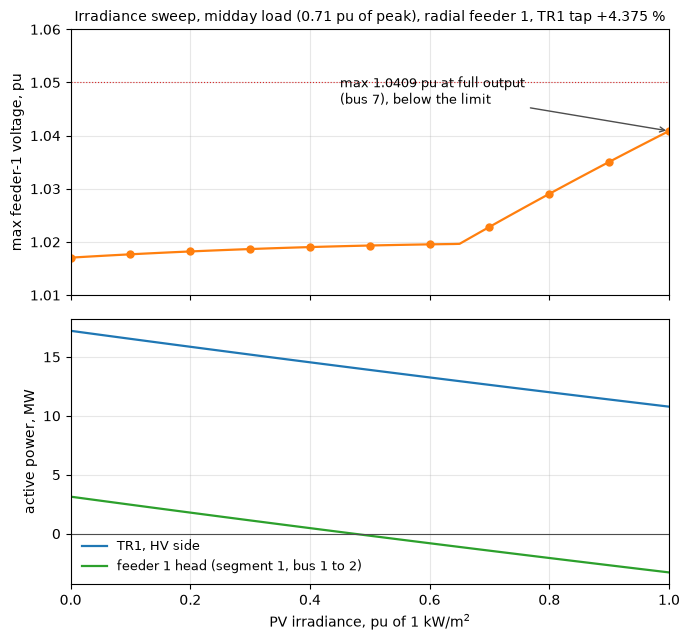

In [7]:
def sweep_irradiance(res_pu, ci_pu, irr_values):
    cd.build_circuit(tr1_tap_pct=TR1_TAP); cd.add_pv(cd.PV_KW); cd.scale_loads(res_pu, ci_pu)
    out = []
    for x in irr_values:
        cd.set_pv_irradiance(x); cd.solve()
        v = cd.bus_voltages_pu(); t = cd.transformer_results(); p1, _ = cd.line_pq(1)
        vmax, bmax = max((v[b], b) for b in range(1, 12))
        out.append(dict(irr=x, vmax=vmax, bmax=bmax, p_tr1=t["TR1"]["p_hv_mw"], p_head=p1,
                        n_viol=sum(v[b] > 1.05 for b in range(1, 12))))
    return out
IRR = np.round(np.arange(0, 1.001, 0.01), 2)
fine = sweep_irradiance(*MID, IRR)
coarse = [r for r in fine if round(r["irr"] * 10, 6) % 1 == 0]
print(f"{'irr':>4s} {'max V pu':>9s} {'at bus':>6s} {'>1.05':>5s} {'TR1 MW':>8s} {'seg1 MW':>8s}")
for r in coarse:
    print(f"{r['irr']:4.1f} {r['vmax']:9.4f} {r['bmax']:6d} {r['n_viol']:5d} {r['p_tr1']:+8.3f} {r['p_head']:+8.3f}")
cross = next((r for r in fine if r["vmax"] >= 1.05), None)
rev = next((r for r in fine if r["p_head"] < 0), None)
IRR_CROSS_MID = cross["irr"] if cross else None
if cross:
    print(f"\n1.05 pu first reached at irradiance {IRR_CROSS_MID:.2f} (PV output {IRR_CROSS_MID*PV_TOTAL_KW/1e3:.2f} MW), at bus {cross['bmax']}")
else:
    print(f"\nno bus reaches 1.05 pu at this load: maximum {fine[-1]['vmax']:.4f} pu at bus {fine[-1]['bmax']} at full output")
print(f"feeder-1 head (segment 1) reverses at irradiance {rev['irr']:.2f} (PV output {rev['irr']*PV_TOTAL_KW/1e3:.2f} MW)")
print(f"TR1 HV-side P at full output: {fine[-1]['p_tr1']:+.3f} MW (no reversal: the bus-1 lumped load alone is "
      f"{sum(cd._LOAD_BASE[n][0] * (MID[0] if n.endswith('_res') else MID[1]) for n in cd._LOAD_BASE if n.startswith('b1_'))/1e3:.2f} MW at midday)")

irr = [r["irr"] for r in fine]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6.5), sharex=True)
ax1.plot(irr, [r["vmax"] for r in fine], color="tab:orange", lw=1.6)
ax1.plot([r["irr"] for r in coarse], [r["vmax"] for r in coarse], "o", color="tab:orange", ms=5)
ax1.axhline(1.05, color="tab:red", lw=0.8, ls=":")
if cross:
    ax1.axvline(IRR_CROSS_MID, color="tab:red", lw=0.8, ls="--")
    ax1.annotate(f"1.05 pu at irradiance {IRR_CROSS_MID:.2f}\n({IRR_CROSS_MID*PV_TOTAL_KW/1e3:.2f} MW PV)", xy=(IRR_CROSS_MID, 1.05),
                 xytext=(0.25, 1.052), fontsize=9, arrowprops=dict(arrowstyle="->", color="0.3"))
else:
    ax1.annotate(f"max {fine[-1]['vmax']:.4f} pu at full output\n(bus {fine[-1]['bmax']}), below the limit",
                 xy=(1.0, fine[-1]["vmax"]), xytext=(0.45, 1.046), fontsize=9,
                 arrowprops=dict(arrowstyle="->", color="0.3"))
ax1.set_ylabel("max feeder-1 voltage, pu"); ax1.set_ylim(1.01, 1.06); ax1.grid(alpha=0.3)
ax1.set_title(f"Irradiance sweep, midday load ({total_pu(*MID):.2f} pu of peak), radial feeder 1, TR1 tap +{TR1_TAP} %", fontsize=10)
ax2.plot(irr, [r["p_tr1"] for r in fine], color="tab:blue", lw=1.6, label="TR1, HV side")
ax2.plot(irr, [r["p_head"] for r in fine], color="tab:green", lw=1.6, label="feeder 1 head (segment 1, bus 1 to 2)")
ax2.axhline(0, color="0.3", lw=0.8)
ax2.set_xlabel("PV irradiance, pu of 1 kW/m$^2$"); ax2.set_ylabel("active power, MW"); ax2.grid(alpha=0.3)
ax2.legend(loc="lower left", fontsize=9, frameon=False); ax2.set_xlim(0, 1)
plt.tight_layout(); plt.show()

Up to about 60 % irradiance the highest feeder-1 voltage is still bus 1 and it barely
moves. Beyond that the PV buses overtake bus 1 and the maximum climbs almost linearly
with irradiance, but at the weekday midday load of the brochure profiles it stops at
about 1.041 pu: the 1.05 pu limit is not reached at this load. The feeder head reverses
at about half irradiance, so reverse flow on its own is not the problem; the voltage
level is, and that level depends on how much load is present to absorb the PV output.

## 6. Load level: when full PV output violates the limit

The midday load of the brochure profile is a working-day value (about 0.7 pu of peak).
Low-demand days (weekends, holidays, summer) combine full sun with a much lighter
midday load. Two sweeps quantify the effect, with the radial feeder at the chosen tap:

- the load is scaled down from the midday level with the same residential to
  commercial/industrial mix, PV at full output, to find the load below which a bus
  exceeds 1.05 pu;
- the irradiance sweep of step 5 is repeated at the lightest level of the daily profiles
  (the light-load extreme of the tap scan), which bounds what a low-demand day can look
  like, to find the crossing irradiance there.

full sun (6.44 MW): 1.05 pu first exceeded when the total load falls below 0.61 pu of peak (0.86 x the midday level, 27.3 MW), at bus 7

 load pu  max V pu at bus >1.05

   0.710    1.0409      7     0

   0.639    1.0477      7     0

   0.568    1.0544      7     9

...

   0.284    1.0800     11     9

   0.213    1.0861     11    10

   0.142    1.0921     11    10

   0.071    1.0979     11    10


lightest load (0.21 pu of peak): 1.05 pu first reached at irradiance 0.35 (PV output 2.25 MW), at bus 7; max 1.0863 pu at bus 11 at full output, 10 buses > 1.05

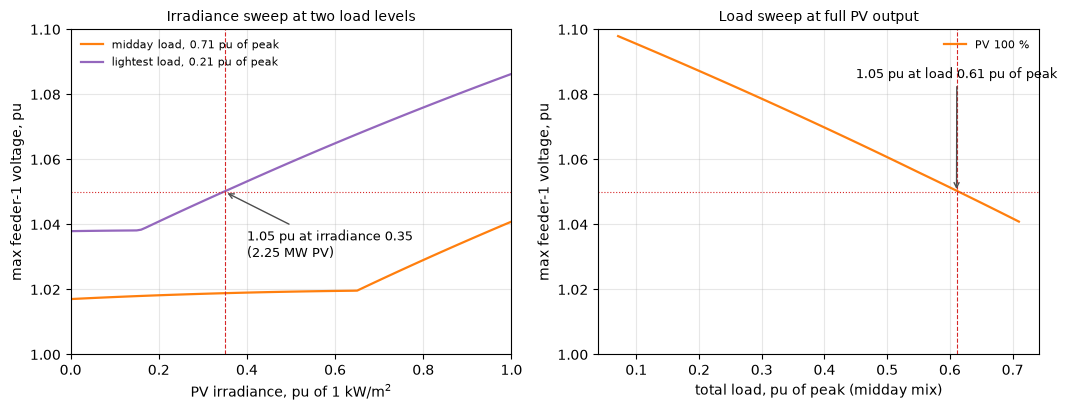

In [8]:
# full sun, load scaled down from the midday mix
FRAC = np.round(np.arange(1.0, 0.09, -0.01), 2)
cd.build_circuit(tr1_tap_pct=TR1_TAP); cd.add_pv(cd.PV_KW); cd.set_pv_irradiance(1.0)
load_sweep = []
for s in FRAC:
    cd.scale_loads(MID[0] * s, MID[1] * s); cd.solve()
    v = cd.bus_voltages_pu()
    vmax, bmax = max((v[b], b) for b in range(1, 12))
    load_sweep.append(dict(frac=s, load_pu=total_pu(MID[0] * s, MID[1] * s), vmax=vmax, bmax=bmax,
                           n_viol=sum(v[b] > 1.05 for b in range(1, 12))))
thr = next(r for r in load_sweep if r["vmax"] >= 1.05)
LOAD_THR = thr["load_pu"]
print(f"full sun ({PV_TOTAL_KW/1e3:.2f} MW): 1.05 pu first exceeded when the total load falls below "
      f"{LOAD_THR:.2f} pu of peak ({thr['frac']:.2f} x the midday level, {LOAD_THR*(peak_res+peak_ci)/1e3:.1f} MW), at bus {thr['bmax']}")
print(f"{'load pu':>8s} {'max V pu':>9s} {'at bus':>6s} {'>1.05':>5s}")
for r in load_sweep[::10]:
    print(f"{r['load_pu']:8.3f} {r['vmax']:9.4f} {r['bmax']:6d} {r['n_viol']:5d}")

# irradiance sweep at the lightest load level of the daily profiles
fine_light = sweep_irradiance(LIGHT[1], LIGHT[2], IRR)
cross_light = next(r for r in fine_light if r["vmax"] >= 1.05)
IRR_CROSS_LIGHT = cross_light["irr"]
print(f"\nlightest load ({total_pu(*LIGHT[1:]):.2f} pu of peak): 1.05 pu first reached at irradiance {IRR_CROSS_LIGHT:.2f} "
      f"(PV output {IRR_CROSS_LIGHT*PV_TOTAL_KW/1e3:.2f} MW), at bus {cross_light['bmax']}; "
      f"max {fine_light[-1]['vmax']:.4f} pu at bus {fine_light[-1]['bmax']} at full output, {fine_light[-1]['n_viol']} buses > 1.05")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.plot(irr, [r["vmax"] for r in fine], color="tab:orange", lw=1.6, label=f"midday load, {total_pu(*MID):.2f} pu of peak")
ax1.plot(irr, [r["vmax"] for r in fine_light], color="tab:purple", lw=1.6, label=f"lightest load, {total_pu(*LIGHT[1:]):.2f} pu of peak")
ax1.axhline(1.05, color="tab:red", lw=0.8, ls=":")
ax1.axvline(IRR_CROSS_LIGHT, color="tab:red", lw=0.8, ls="--")
ax1.annotate(f"1.05 pu at irradiance {IRR_CROSS_LIGHT:.2f}\n({IRR_CROSS_LIGHT*PV_TOTAL_KW/1e3:.2f} MW PV)", xy=(IRR_CROSS_LIGHT, 1.05),
             xytext=(0.40, 1.030), fontsize=9, arrowprops=dict(arrowstyle="->", color="0.3"))
ax1.set_xlim(0, 1); ax1.set_ylim(1.0, 1.10); ax1.grid(alpha=0.3)
ax1.set_xlabel("PV irradiance, pu of 1 kW/m$^2$"); ax1.set_ylabel("max feeder-1 voltage, pu")
ax1.set_title("Irradiance sweep at two load levels", fontsize=10)
ax1.legend(loc="upper left", fontsize=8, frameon=False)
ax2.plot([r["load_pu"] for r in load_sweep], [r["vmax"] for r in load_sweep], color="tab:orange", lw=1.6, label="PV 100 %")
ax2.axhline(1.05, color="tab:red", lw=0.8, ls=":")
ax2.axvline(LOAD_THR, color="tab:red", lw=0.8, ls="--")
ax2.annotate(f"1.05 pu at load {LOAD_THR:.2f} pu of peak", xy=(LOAD_THR, 1.05), xytext=(0.45, 1.085), fontsize=9,
             arrowprops=dict(arrowstyle="->", color="0.3"))
ax2.set_ylim(1.0, 1.10); ax2.grid(alpha=0.3)
ax2.set_xlabel("total load, pu of peak (midday mix)"); ax2.set_ylabel("max feeder-1 voltage, pu")
ax2.set_title("Load sweep at full PV output", fontsize=10)
ax2.legend(loc="upper right", fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

## 7. Voltage at the PV buses at full output

Bar chart of the voltage at each of the nine PV buses with PV at 100 %, at the midday
load (left) and at the lightest load level (right). Bars above 1.05 pu are drawn in
red, the others in grey; the label gives the margin to the limit.

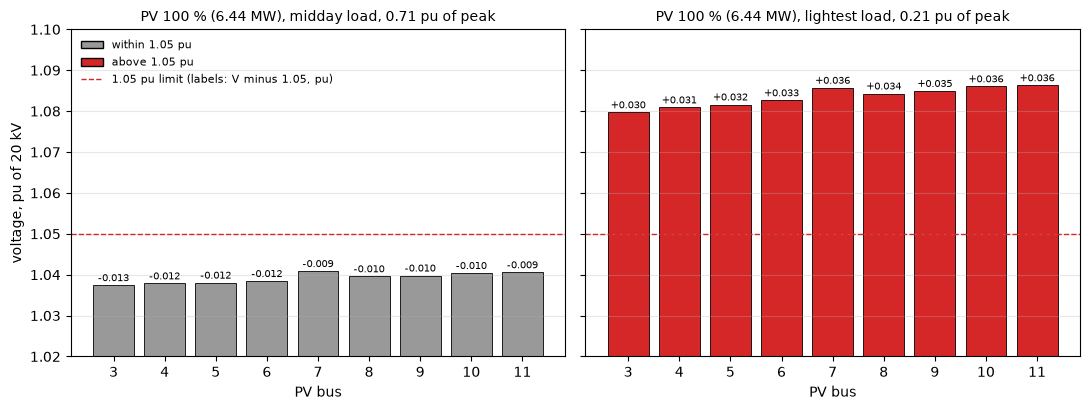

midday load   : buses above 1.05 pu none; highest 1.0409 pu at bus 7, lowest PV bus 1.0374 pu at bus 3; bus 2 1.0265, bus 1 1.0197

lightest load : buses above 1.05 pu [3, 4, 5, 6, 7, 8, 9, 10, 11]; highest 1.0863 pu at bus 11, lowest PV bus 1.0797 pu at bus 3; bus 2 1.0532, bus 1 1.0368

In [9]:
cd.build_circuit(tr1_tap_pct=TR1_TAP); cd.add_pv(cd.PV_KW); cd.scale_loads(LIGHT[1], LIGHT[2]); cd.set_pv_irradiance(1.0); cd.solve()
v_light = cd.bus_voltages_pu()
vc = cases["(c) midday, PV 100 %"]["v"]
buses = list(cd.PV_KW)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, v, title in zip(axes, (vc, v_light),
                        (f"midday load, {total_pu(*MID):.2f} pu of peak", f"lightest load, {total_pu(*LIGHT[1:]):.2f} pu of peak")):
    vals = [v[b] for b in buses]
    cols = ["tab:red" if x > 1.05 else "0.6" for x in vals]
    bars = ax.bar([str(b) for b in buses], vals, color=cols, edgecolor="black", lw=0.6)
    ax.axhline(1.05, color="tab:red", lw=1, ls="--")
    for bar, x in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, x + 0.001, f"{x-1.05:+.3f}", ha="center", fontsize=7.5)
    ax.set_xlabel("PV bus"); ax.set_title(f"PV 100 % ({PV_TOTAL_KW/1e3:.2f} MW), {title}", fontsize=10); ax.grid(axis="y", alpha=0.3)
axes[0].set_ylim(1.02, 1.10); axes[0].set_ylabel("voltage, pu of 20 kV")
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
axes[0].legend(handles=[Patch(facecolor="0.6", edgecolor="black", label="within 1.05 pu"),
                        Patch(facecolor="tab:red", edgecolor="black", label="above 1.05 pu"),
                        Line2D([], [], color="tab:red", lw=1, ls="--", label="1.05 pu limit (labels: V minus 1.05, pu)")],
               loc="upper left", frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

for lab, v in (("midday load", vc), ("lightest load", v_light)):
    vals = [v[b] for b in buses]
    viol = [b for b in buses if v[b] > 1.05]
    print(f"{lab:14s}: buses above 1.05 pu {viol if viol else 'none'}; highest {max(vals):.4f} pu at bus {buses[vals.index(max(vals))]}, "
          f"lowest PV bus {min(vals):.4f} pu at bus {buses[vals.index(min(vals))]}; bus 2 {v[2]:.4f}, bus 1 {v[1]:.4f}")

## 8. Summary

- With TR1 at +4.375 % the feeder without PV stays within 0.95 to 1.05 pu at every load
  level of the brochure daily profiles (0.963 to 1.038 pu at the two extremes), so all
  violations in this study are caused by PV. The brochure tap of +6.25 % would put bus 1
  above the limit at every light-load hour even without PV.
- With the nine PV units of Wagle et al. (6.44 MW in total, unity power factor) at full
  output and the weekday midday load, feeder 1 rises to about 1.041 pu at bus 7, the end
  of the lateral fed through bus 8, with the PV buses within 0.4 % of each other: the
  PV effect is a feeder-wide level, not a local hot spot, and at this load it stays
  inside the band. Meshing feeder 1 (S2 and S3 closed) redistributes the flow but does
  not change the level. Feeder 2 is unaffected.
- The violation is a matter of load level. At full output the limit is exceeded as soon
  as the total load falls below about 0.61 pu of peak (step 6), which any low-demand
  day does at midday. At the lightest level of the daily profiles (0.21 pu of peak)
  the limit is reached at about 35 % irradiance, and at full output all nine PV buses
  and bus 2 exceed 1.05 pu, the worst by about 3.6 % (bus 11, about 1.086 pu); the
  exact values are printed in steps 6 and 7.
- TR1 as a whole never reverses, because the 15 MVA lumped load at bus 1 exceeds the
  PV output; the feeder head (segment 1) does reverse at about half irradiance, well
  before any voltage limit.
- The PV case agrees with a pandapower solution of the same data to better than
  1e-4 %, so the numbers above are a property of the network data, the tap and the PV
  sizes, not of the tool.

The next notebook builds a year of load and irradiance profiles at 15-minute resolution
and runs it as a quasi-static time series, to count for how many hours the violations
occur and where they fall in the day and in the year.

Files: `cigre_dss.py` (with `PV_KW`, `add_pv`, `set_pv_irradiance`, `scale_loads`,
`pv_results`, `line_pq`, `bus_voltages_pu`, and `pv_kw`/`sector_scale`/`tr1_tap_pct`
in the pandapower reference) and this notebook.